# Simple Trade Viewer

Load Stage 1 artifacts from the `data/` directory and visualise a labelled trade window as candlesticks.


In [69]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
from typing import Optional, Tuple, List

# --------- File loaders -------------------------------------------------------
def _load_parquet_or_csv(path_base: Path) -> pd.DataFrame:
    """Try .parquet then .csv (Stage1 writes parquet, falls back to csv)."""
    pq = path_base.with_suffix(".parquet")
    if pq.exists():
        return pd.read_parquet(pq)
    csv = path_base.with_suffix(".csv")
    if csv.exists():
        # processed has index as datetime; dataset has 'ts' column
        try:
            df = pd.read_csv(csv, parse_dates=True, index_col=0)
        except Exception:
            df = pd.read_csv(csv)
        return df
    raise FileNotFoundError(f"Neither {pq} nor {csv} found")

def load_processed(symbol: str, interval: str, root: Path = Path("../data/processed")) -> pd.DataFrame:
    """Load OHLCV, expecting index as datetime and columns: open, high, low, close, volume."""
    base = root / f"{symbol}_{interval}"
    df = _load_parquet_or_csv(base)
    # Normalize index to datetime index (tz aware is fine)
    if not isinstance(df.index, pd.DatetimeIndex):
        # try to detect column with timestamps
        for cand in ("ts","time","datetime","date"):
            if cand in df.columns:
                df[cand] = pd.to_datetime(df[cand], errors="coerce", utc=True)
                df = df.set_index(cand)
                break
    df = df.sort_index()
    # sanity columns
    needed = ["open","high","low","close"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Processed file missing columns: {missing}")
    return df

def load_dataset(symbol: str, interval: str, backW: int, forW: int,
                 root: Path = Path("../data/datasets")) -> pd.DataFrame:
    base = root / f"{symbol}_{interval}_backW{backW}_forW{forW}"
    df = _load_parquet_or_csv(base)
    # Ensure ts is datetime (dataset is not indexed by ts)
    if "ts" in df.columns:
        df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
    else:
        # maybe first col is ts
        first = df.columns[0]
        df[first] = pd.to_datetime(df[first], errors="coerce", utc=True)
        df = df.rename(columns={first: "ts"})
    # Normalize label column type
    if "label" in df.columns:
        df["label"] = df["label"].astype("string")
    return df.sort_values("ts")

# --------- Trade pairing (entry -> exit) -------------------------------------
def build_trade_table(processed: pd.DataFrame, dataset: pd.DataFrame, forW: int) -> pd.DataFrame:
    """
    For each dataset row (entry at ts), find exit candle = ts index + forW.
    Compute entry/exit prices and forward return ((ExitClose - EntryOpen)/EntryOpen - fee).
    Only BUY/SELL are returned.
    """
    # map timestamps to integer positions
    proc_idx = processed.index
    ts_to_pos = pd.Series(range(len(proc_idx)), index=proc_idx)

    # keep only rows whose ts aligns to processed index
    d = dataset[dataset["ts"].isin(proc_idx)].copy()
    d = d[d["label"].isin(["BUY","SELL"])].copy()
    if d.empty:
        return d.assign(entry_pos=np.nan, exit_pos=np.nan, entry_open=np.nan, exit_close=np.nan, forward=np.nan)

    d["entry_pos"] = d["ts"].map(ts_to_pos)
    d["exit_pos"]  = d["entry_pos"] + forW

    # drop trades that don't have a full forward window
    valid_mask = d["exit_pos"] < len(processed)
    d = d[valid_mask].copy()

    # gather prices
    d["entry_open"] = processed["open"].to_numpy()[d["entry_pos"].to_numpy()]
    d["exit_close"] = processed["close"].to_numpy()[d["exit_pos"].to_numpy()]
    # fee column may be missing in some datasets; default 0 if so
    fee = d["fee"] if "fee" in d.columns else 0.0
    d["forward"] = (d["exit_close"] - d["entry_open"]) / d["entry_open"] - fee

    # materialize exit timestamps for plotting
    d["exit_ts"] = processed.index.to_numpy()[d["exit_pos"].to_numpy()]
    return d

# --------- Simple candlestick (no custom colors) ------------------------------
def draw_candles(ax, df: pd.DataFrame) -> List[pd.Timestamp]:
    """
    Minimal OHLC candles without specifying colors:
    - wick: thin vertical line from low to high
    - body: thicker vertical line from open to close
    Returns list of x positions aligned to df.index.
    """
    xs = list(range(len(df)))
    o = df["open"].to_numpy()
    h = df["high"].to_numpy()
    l = df["low"].to_numpy()
    c = df["close"].to_numpy()

    for i, (lo, hi, op, cl) in enumerate(zip(l, h, o, c)):
        ax.plot([i, i], [lo, hi])              # wick
        ax.plot([i, i], [op, cl], linewidth=5) # body (thicker)
    ax.set_xlim(-1, len(df))
    return xs

# --------- Plotting trades over candles ---------------------------------------
def plot_trades_on_candles(
    processed: pd.DataFrame,
    trades: pd.DataFrame,
    *,
    start: Optional[pd.Timestamp] = None,
    end: Optional[pd.Timestamp] = None,
    max_trades: Optional[int] = 300,
    title: Optional[str] = None
) -> None:
    """
    Draw candles for [start:end] and overlay BUY/SELL entries (▲/▼), exits (×),
    and shaded spans between entry and exit. Uses default matplotlib styles/colors.
    """
    # slice candle range
    if start is not None or end is not None:
        proc_slice = processed.loc[start:end]
    else:
        proc_slice = processed
    if proc_slice.empty:
        raise ValueError("No candles in the selected range")

    fig, ax = plt.subplots(figsize=(12, 6))
    draw_candles(ax, proc_slice)

    # map visible timestamps -> local x positions
    vis_idx = proc_slice.index
    vis_pos = pd.Series(range(len(vis_idx)), index=vis_idx)

    # filter trades to visible window
    t = trades.copy()
    t = t[t["ts"].between(vis_idx[0], vis_idx[-1])]
    if max_trades is not None and len(t) > max_trades:
        t = t.sort_values("ts").head(max_trades)

    # overlay trades
    for _, row in t.iterrows():
        x_entry = vis_pos.get(row["ts"])
        x_exit  = vis_pos.get(row["exit_ts"])
        if pd.isna(x_entry) or pd.isna(x_exit):
            continue
        # entry marker at entry open
        if row["label"] == "BUY":
            ax.scatter([x_entry], [row["entry_open"]], marker="^")
        else:  # SELL
            ax.scatter([x_entry], [row["entry_open"]], marker="v")
        # exit marker at exit close
        ax.scatter([x_exit], [row["exit_close"]], marker="x")
        # shaded holding period
        ax.axvspan(x_entry - 0.4, x_exit + 0.4, alpha=0.15)
        # annotate forward return (percent)
        ax.annotate(f"{row['label']}  {row['forward']*100:.2f}%",
                    (x_entry, row["entry_open"]),
                    xytext=(5, 8), textcoords="offset points")

    ax.set_xlabel("Time")
    ax.set_ylabel("Price")
    if title:
        ax.set_title(title)
    ax.grid(True, which="both", axis="both", linewidth=0.5)
    # xticks as timestamps (sparse)
    xticks = np.linspace(0, len(vis_idx) - 1, num=min(8, len(vis_idx)), dtype=int)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(vis_idx[i]).split("+")[0] for i in xticks], rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

# --------- One-liner helper for your exact setup ------------------------------
def visualize_stage1_trades(
    symbol: str,
    interval: str,
    backW: int,
    forW: int,
    *,
    date_start: Optional[str] = None,
    date_end: Optional[str] = None,
    max_trades: Optional[int] = 300,
    return_processed: bool = False
):
    processed = load_processed(symbol, interval)
    dataset   = load_dataset(symbol, interval, backW, forW)
    trades    = build_trade_table(processed, dataset, forW)

    # windowing
    start = pd.to_datetime(date_start, utc=True) if date_start else None
    end   = pd.to_datetime(date_end, utc=True) if date_end else None

    title = f"{symbol} {interval} | backW={backW} forW={forW} | trades={len(trades)}"
    plot_trades_on_candles(processed, trades, start=start, end=end, max_trades=max_trades, title=title)
    if return_processed:
        return trades, processed
    return trades  # return table for inspection if needed

def summarise_trades(trades: pd.DataFrame) -> pd.Series:
    """Aggregate key performance metrics from the trade table."""
    if trades is None or trades.empty:
        return pd.Series({
            "trades": 0,
            "mean_forward_pct": np.nan,
            "median_forward_pct": np.nan,
            "std_forward_pct": np.nan,
            "win_rate_pct": np.nan,
            "avg_holding_hours": np.nan,
            "total_return_multiplier": np.nan,
            "max_drawdown_pct": np.nan,
            "buy_share_pct": np.nan,
            "sell_share_pct": np.nan,
        })

    t = trades.sort_values("ts")
    if "forward" not in t:
        raise ValueError("Trade table missing 'forward' column")

    forward = t["forward"].astype(float)
    cumulative = (1 + forward).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1

    holding_hours = None
    if "exit_ts" in t and "ts" in t:
        holding_hours = (t["exit_ts"] - t["ts"]).dt.total_seconds() / 3600

    summary = {
        "trades": int(len(t)),
        "mean_forward_pct": forward.mean() * 100,
        "median_forward_pct": forward.median() * 100,
        "std_forward_pct": forward.std(ddof=0) * 100,
        "win_rate_pct": (forward > 0).mean() * 100,
        "avg_holding_hours": holding_hours.mean() if holding_hours is not None else np.nan,
        "total_return_multiplier": cumulative.iloc[-1] if not cumulative.empty else np.nan,
        "max_drawdown_pct": drawdown.min() * 100 if not drawdown.empty else np.nan,
        "buy_share_pct": np.nan,
        "sell_share_pct": np.nan,
    }

    if "label" in t:
        summary["buy_share_pct"] = (t["label"] == "BUY").mean() * 100
        summary["sell_share_pct"] = (t["label"] == "SELL").mean() * 100

    return pd.Series(summary)


def plot_single_trade_window(
    processed: pd.DataFrame,
    trades: pd.DataFrame,
    *,
    trade_number: Optional[int] = None,
    trade_ts: Optional[pd.Timestamp] = None,
    pre_candles: int = 10,
    post_candles: int = 10,
    title: Optional[str] = None
) -> pd.Series:
    """Plot a single trade with surrounding candles and return the selected trade row."""
    if trades is None or trades.empty:
        raise ValueError("No trades available to visualise")

    t = trades.reset_index(drop=True)

    row = None
    if trade_ts is not None:
        if not isinstance(trade_ts, pd.Timestamp):
            trade_ts = pd.to_datetime(trade_ts, utc=True)
        matches = t[t["ts"] == trade_ts]
        if not matches.empty:
            row = matches.iloc[0]
    if row is None:
        if trade_number is None:
            trade_number = 0
        if trade_number < 0 or trade_number >= len(t):
            raise IndexError(f"trade_number {trade_number} is out of range (0..{len(t) - 1})")
        row = t.iloc[int(trade_number)]

    if pd.isna(row.get("entry_pos")) or pd.isna(row.get("exit_pos")):
        raise ValueError("Selected trade is missing entry/exit position data")

    entry_pos = int(row["entry_pos"])
    exit_pos = int(row["exit_pos"])

    start_pos = max(0, entry_pos - max(pre_candles, 0))
    end_pos = min(len(processed), exit_pos + max(post_candles, 0) + 1)
    window = processed.iloc[start_pos:end_pos]
    if window.empty:
        raise ValueError("No candles available for the selected trade window")

    fig, ax = plt.subplots(figsize=(12, 6))
    draw_candles(ax, window)

    vis_idx = window.index
    vis_pos = pd.Series(range(len(vis_idx)), index=vis_idx)

    entry_ts = row["ts"]
    exit_ts = row["exit_ts"]
    x_entry = vis_pos.get(entry_ts)
    x_exit = vis_pos.get(exit_ts)

    entry_label = str(entry_ts).split("+")[0] if pd.notna(entry_ts) else ""
    exit_label = str(exit_ts).split("+")[0] if pd.notna(exit_ts) else ""

    if x_entry is not None:
        marker = "^" if row["label"] == "BUY" else "v"
        ax.scatter([x_entry], [row["entry_open"]], marker=marker, s=90, color="#1f77b4")
        ax.annotate(
            f"Entry ({entry_label})",
            (x_entry, row["entry_open"]),
            xytext=(5, -20),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", linewidth=0.7),
        )
    if x_exit is not None:
        ax.scatter([x_exit], [row["exit_close"]], marker="x", s=80, color="#d62728")
        ax.annotate(
            f"Exit ({exit_label})",
            (x_exit, row["exit_close"]),
            xytext=(5, 12),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", linewidth=0.7),
        )
    if x_entry is not None and x_exit is not None:
        ax.axvspan(x_entry - 0.4, x_exit + 0.4, alpha=0.18, color="#c5b0d5")
        ax.annotate(
            f"Forward: {row['forward']*100:.2f}%",
            (x_entry, max(row["entry_open"], row["exit_close"])),
            xytext=(10, 10),
            textcoords="offset points",
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Price")
    trade_label = row.get("label", "")
    trade_title = title or f"Trade {row.name} {trade_label}".strip()
    ax.set_title(trade_title)
    xticks = np.linspace(0, len(vis_idx) - 1, num=min(8, len(vis_idx)), dtype=int)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(vis_idx[i]).split("+")[0] for i in xticks], rotation=30, ha="right")
    ax.grid(True, linestyle=":", linewidth=0.5)
    ax.set_xlim(-1, len(window))

    plt.tight_layout()
    plt.show()

    return row

def plot_trade_statistics(trades: pd.DataFrame) -> None:
    """Render common risk/return visualisations for the computed trades."""
    if trades is None or trades.empty:
        print("No trades available for statistics.")
        return
    if "forward" not in trades:
        print("Trade table missing 'forward' column.")
        return

    t = trades.sort_values("ts")
    forward_pct = t["forward"].astype(float) * 100

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Forward return distribution
    bins = min(50, max(10, int(np.sqrt(len(forward_pct))) if len(forward_pct) > 0 else 1))
    axes[0, 0].hist(forward_pct, bins=bins, color="#4c72b0", alpha=0.85)
    axes[0, 0].axvline(forward_pct.mean(), color="black", linestyle="--", linewidth=1, label="mean")
    axes[0, 0].axvline(forward_pct.median(), color="#dd8452", linestyle=":", linewidth=1, label="median")
    axes[0, 0].set_title("Forward Return Distribution (%)")
    axes[0, 0].set_xlabel("Return (%)")
    axes[0, 0].set_ylabel("Count")
    axes[0, 0].legend()

    # Return by label
    if "label" in t and not t["label"].dropna().empty:
        labels = []
        groups = []
        for lbl in sorted(t["label"].dropna().unique()):
            values = forward_pct[t["label"] == lbl]
            if not values.empty:
                labels.append(lbl)
                groups.append(values)
        if groups:
            boxes = axes[0, 1].boxplot(groups, labels=labels, patch_artist=True)
            for patch, lbl in zip(boxes['boxes'], labels):
                patch.set_facecolor("#55a868" if lbl == "BUY" else "#c44e52")
            axes[0, 1].set_title("Forward Return by Label (%)")
            axes[0, 1].set_ylabel("Return (%)")
        else:
            axes[0, 1].axis("off")
            axes[0, 1].text(0.5, 0.5, "No labelled trades", ha="center", va="center")
    else:
        axes[0, 1].axis("off")
        axes[0, 1].text(0.5, 0.5, "Label column missing", ha="center", va="center")

    # Cumulative return
    cumulative = (1 + t["forward"].astype(float)).cumprod()
    locator = AutoDateLocator()
    formatter = AutoDateFormatter(locator)
    axes[1, 0].plot(t["ts"], cumulative, marker="o", linewidth=1.5, color="#c44e52")
    axes[1, 0].axhline(1, color="gray", linestyle="--", linewidth=1)
    axes[1, 0].set_title("Cumulative Return Multiplier")
    axes[1, 0].set_ylabel("Multiplier")
    axes[1, 0].xaxis.set_major_locator(locator)
    axes[1, 0].xaxis.set_major_formatter(formatter)
    axes[1, 0].tick_params(axis="x", rotation=30)
    axes[1, 0].grid(True, linestyle=":", linewidth=0.5)

    # Holding period distribution
    if "exit_ts" in t and "ts" in t:
        holding_hours = (t["exit_ts"] - t["ts"]).dt.total_seconds() / 3600
        if not holding_hours.empty:
            bins_hold = min(30, max(5, int(np.sqrt(len(holding_hours))) if len(holding_hours) > 0 else 1))
            axes[1, 1].hist(holding_hours, bins=bins_hold, color="#55a868", alpha=0.85)
            axes[1, 1].set_title("Holding Period Distribution (hours)")
            axes[1, 1].set_xlabel("Hours")
            axes[1, 1].set_ylabel("Count")
        else:
            axes[1, 1].axis("off")
            axes[1, 1].text(0.5, 0.5, "No holding period data", ha="center", va="center")
    else:
        axes[1, 1].axis("off")
        axes[1, 1].text(0.5, 0.5, "exit_ts missing", ha="center", va="center")

    fig.tight_layout()
    plt.show()


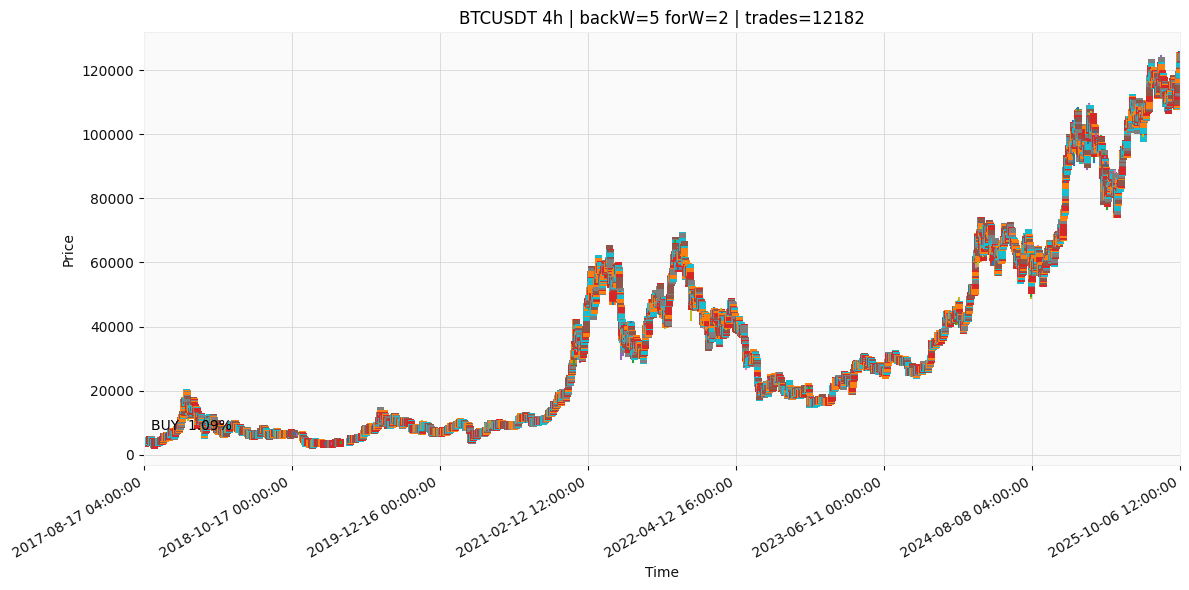

                             value
trades                  12182.0000
mean_forward_pct           -0.1319
median_forward_pct         -0.6047
std_forward_pct             2.4142
win_rate_pct               44.9926
avg_holding_hours           8.0069
total_return_multiplier     0.0000
max_drawdown_pct         -100.0000
buy_share_pct              44.9926
sell_share_pct             55.0074


/tmp/ipykernel_55182/992767608.py:392: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = axes[0, 1].boxplot(groups, labels=labels, patch_artist=True)


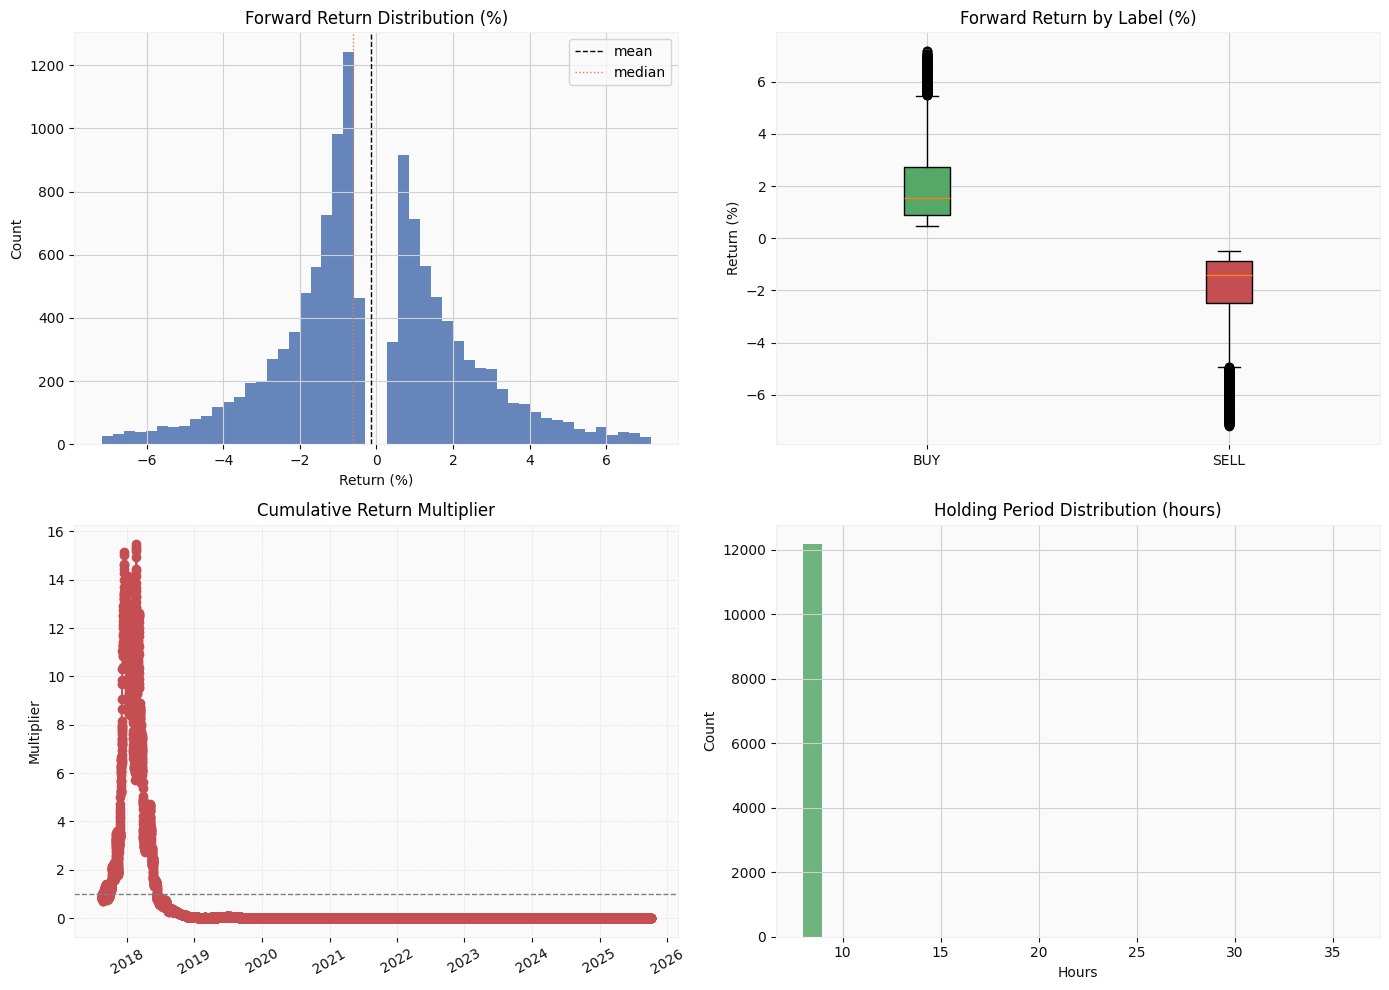

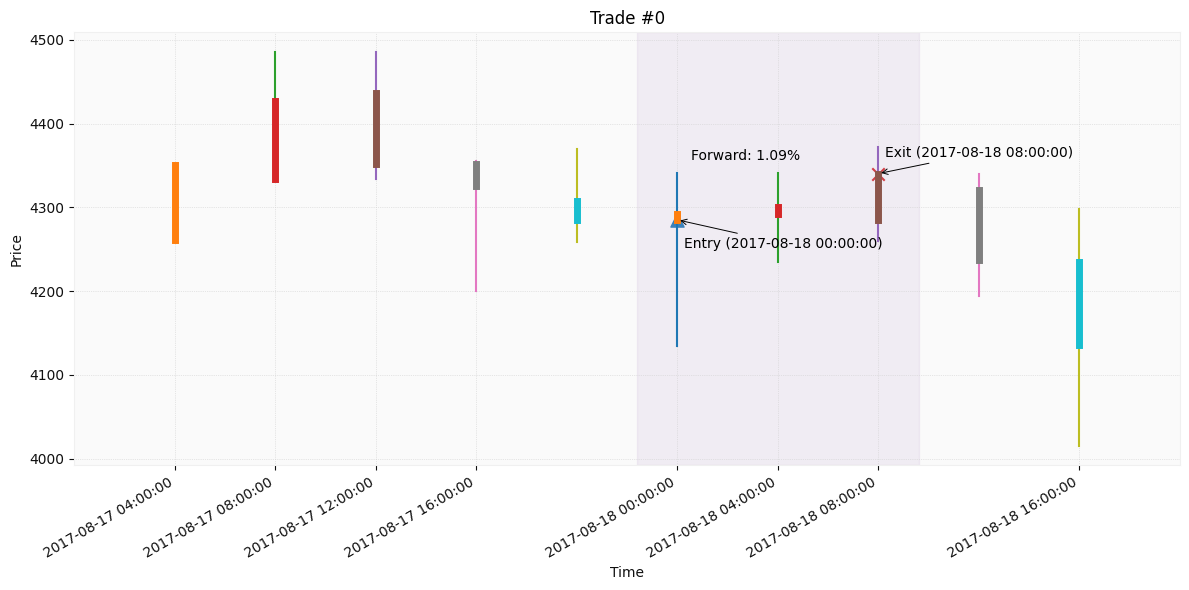

Selected trade details:
                          ts label backW forW     alpha     beta    fee  \
0  2017-08-18 00:00:00+00:00   BUY     5    2  0.004826  0.07174  0.002   

     ema_backW entry_pos exit_pos entry_open exit_close   forward  \
0  4318.019877         5        7    4285.08    4340.31  0.010889   

                     exit_ts  
0  2017-08-18 08:00:00+00:00  


In [70]:
symbol = "BTCUSDT"
interval = "4h"
backW = 5
forW = 2

default_start = None
default_end = None

trades, processed = visualize_stage1_trades(
    symbol=symbol,
    interval=interval,
    backW=backW,
    forW=forW,
    date_start=default_start,
    date_end=default_end,
    max_trades=1,
    return_processed=True,
)

summary = summarise_trades(trades)
summary_df = summary.to_frame("value")
with pd.option_context("display.float_format", "{:.4f}".format):
    print(summary_df)

plot_trade_statistics(trades)

if not trades.empty:
    trade_number = 0  # change this index to inspect a different trade
    single_trade = plot_single_trade_window(
        processed,
        trades,
        trade_number=trade_number,
        pre_candles=backW,
        post_candles=forW,
        title=f"Trade #{trade_number}"
    )
    print("Selected trade details:")
    with pd.option_context("display.max_columns", None):
        print(single_trade.to_frame().T)
else:
    print("No trades available for single-trade visualisation.")
